In [2]:
# Exploratory Data Analysis (EDA) Script for Bugra Akkus my other 2 firend will upload with their name
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
df = pd.read_csv('Phishing_URL_ds_cleaned.csv')

1- Domain identifiers
TLD (Top Level Doamin) the suffix of the domain phishing sites often use cheap or obcoure TLDs.
Is DoaminIP returns 1 if domain is an IP address instead of a name. Legitimate public sites rarely use raw IPs.
2- Lexical Features ( URl String Analysis)
these analyze looking to length of the URL. phsishing website generally have long and random URL.
URL

*univariate analyses*

In [3]:
#split columns by data type
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

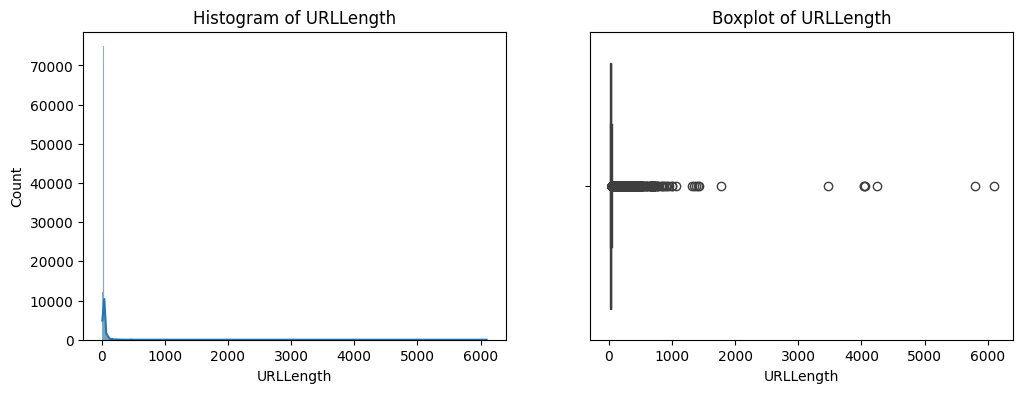

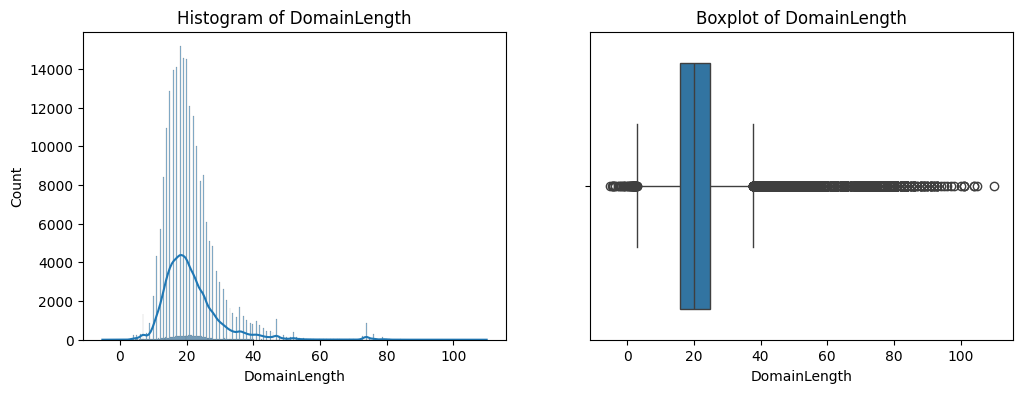

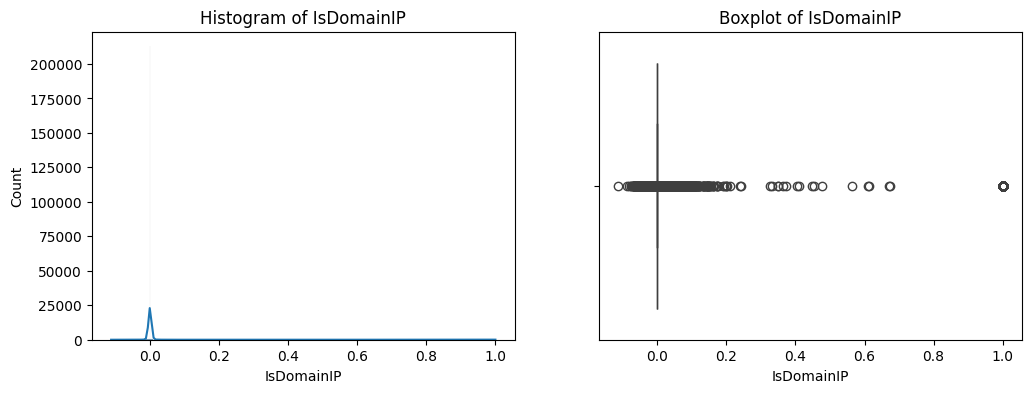

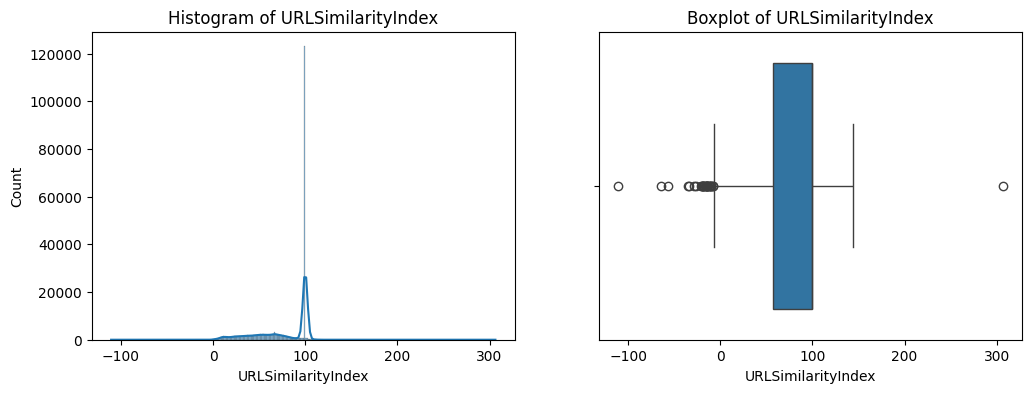

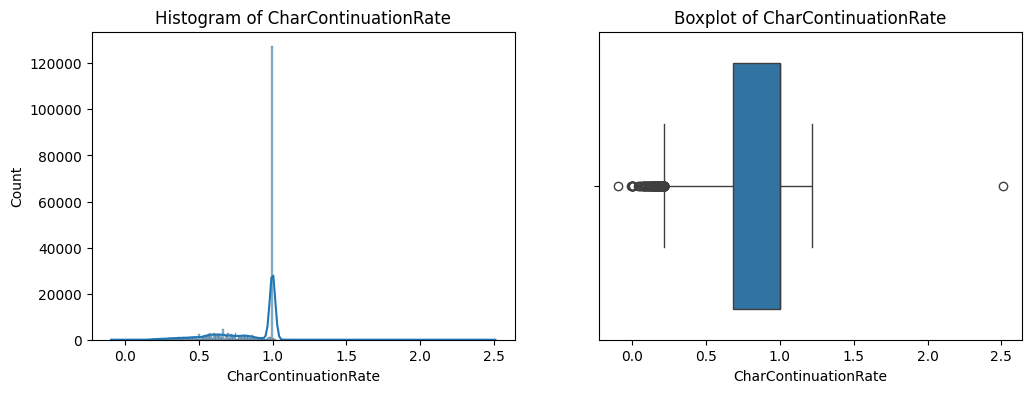

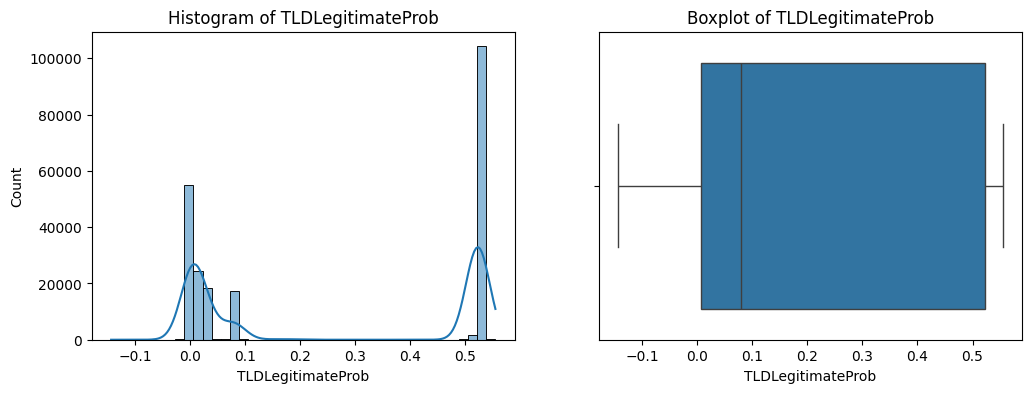

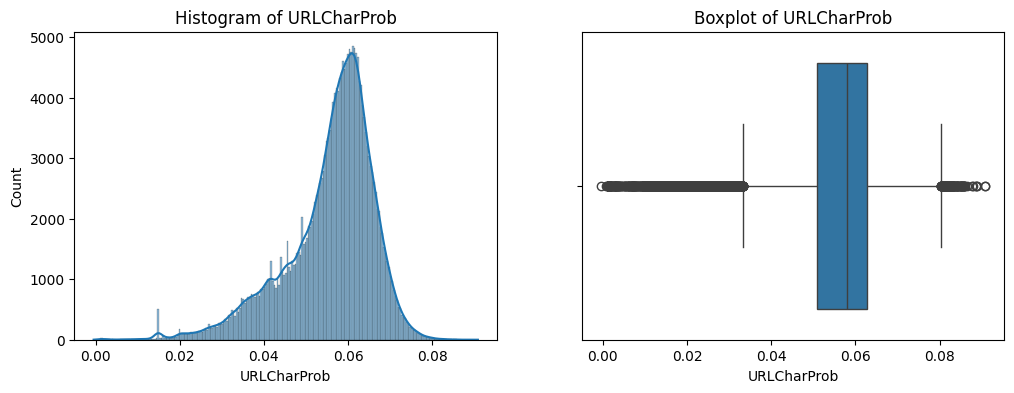

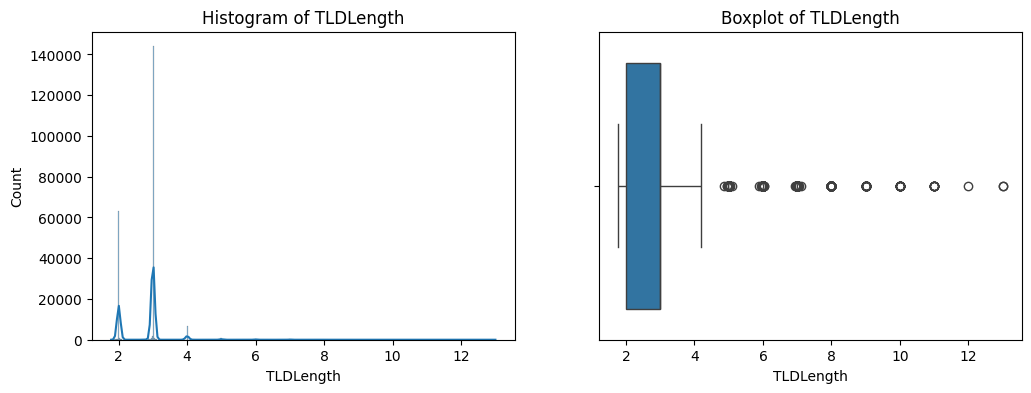

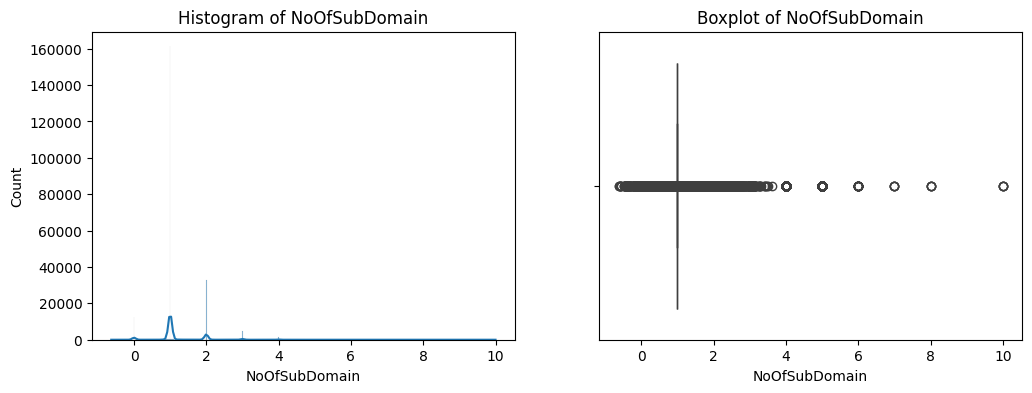

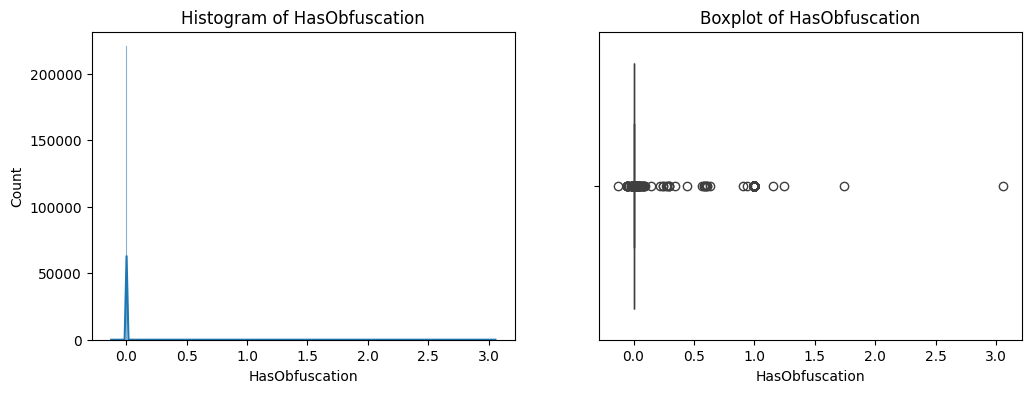

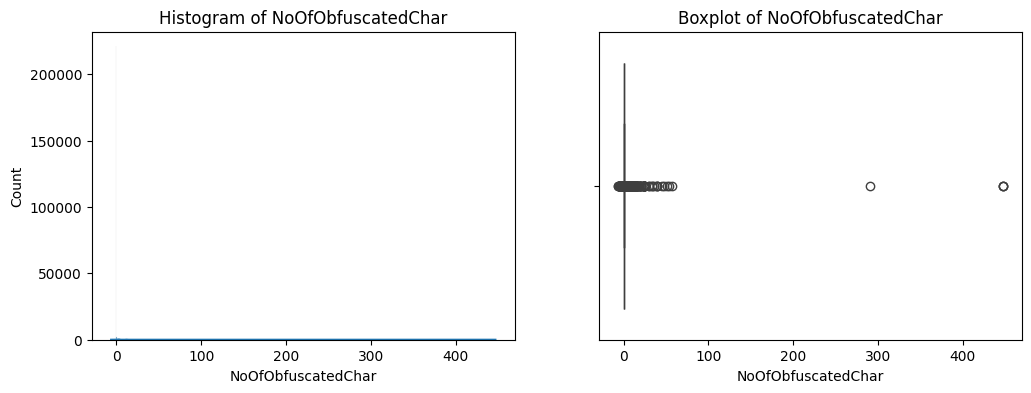

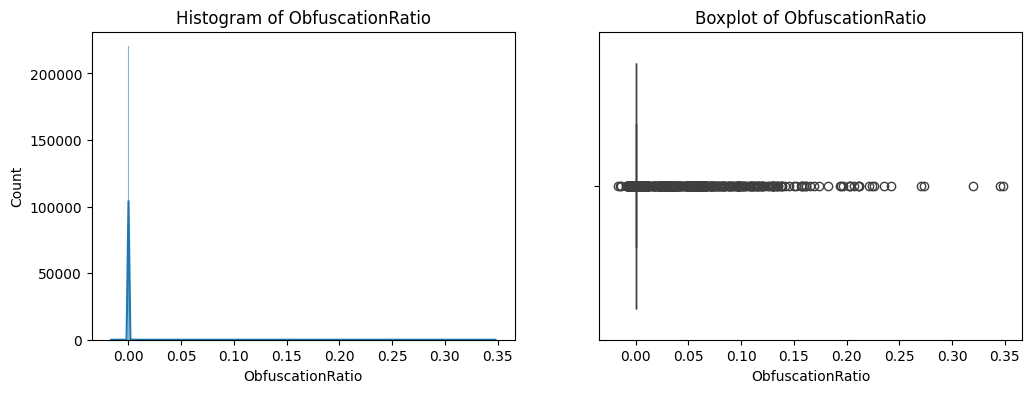

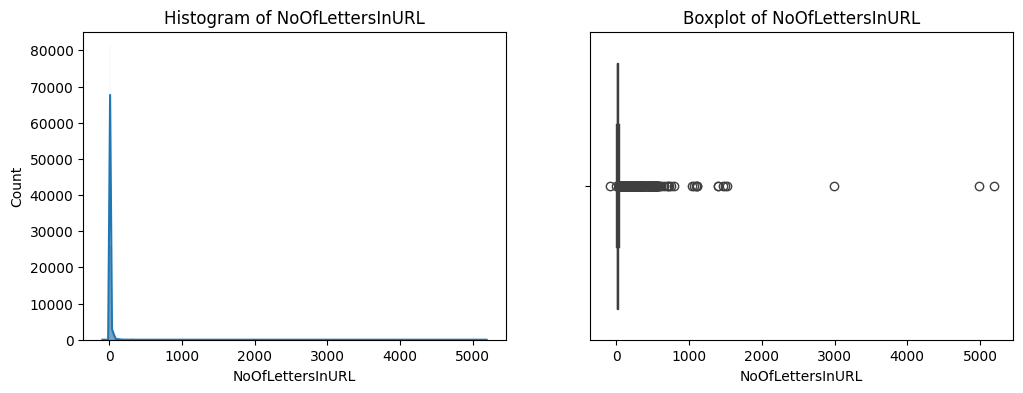

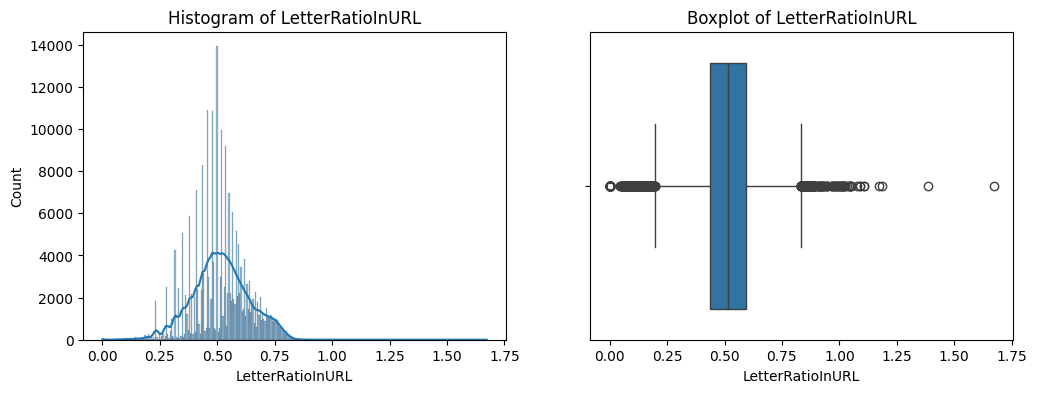

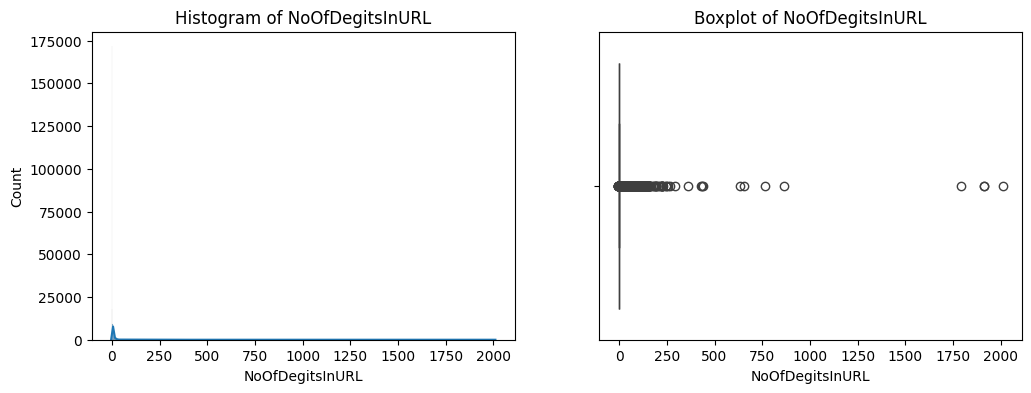

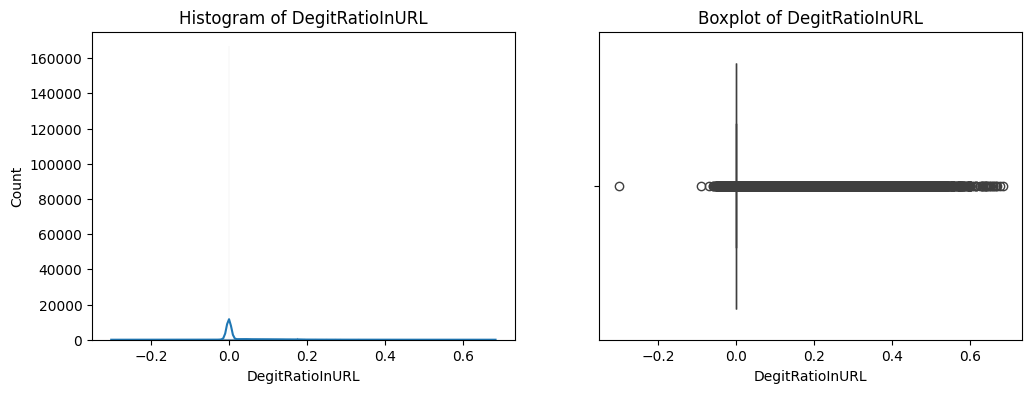

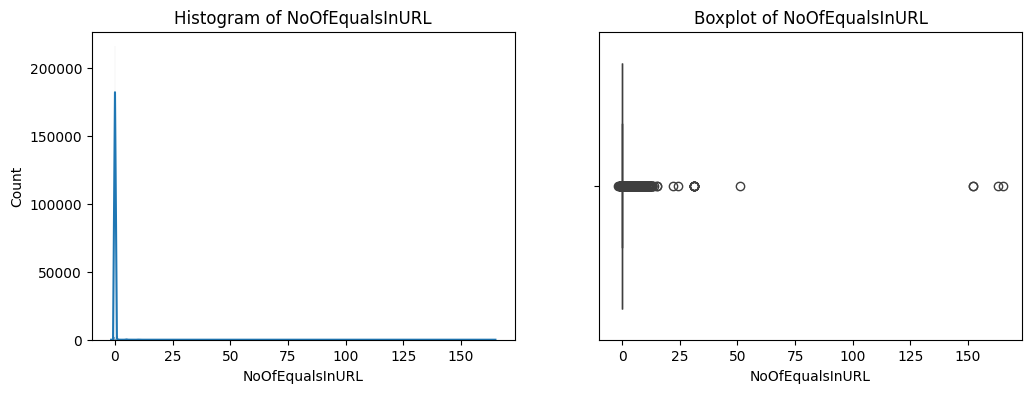

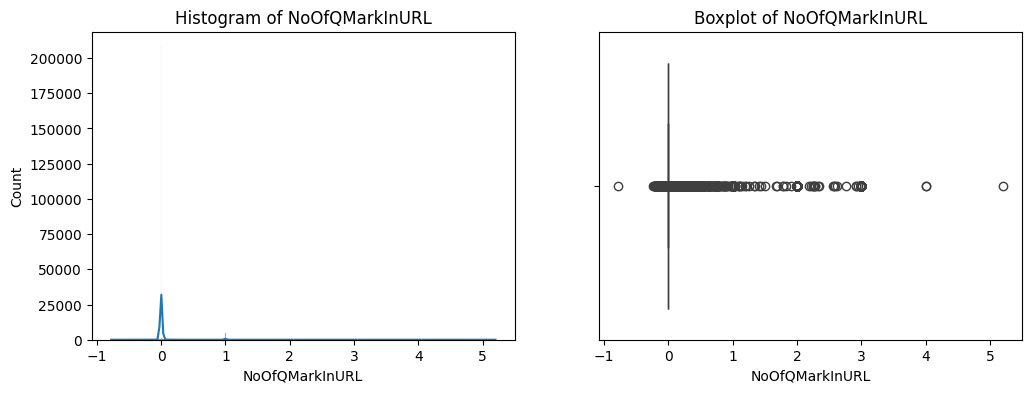

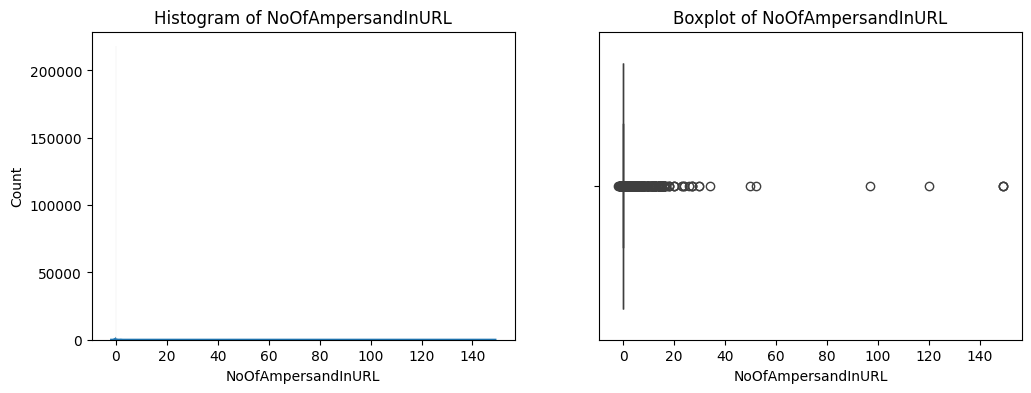

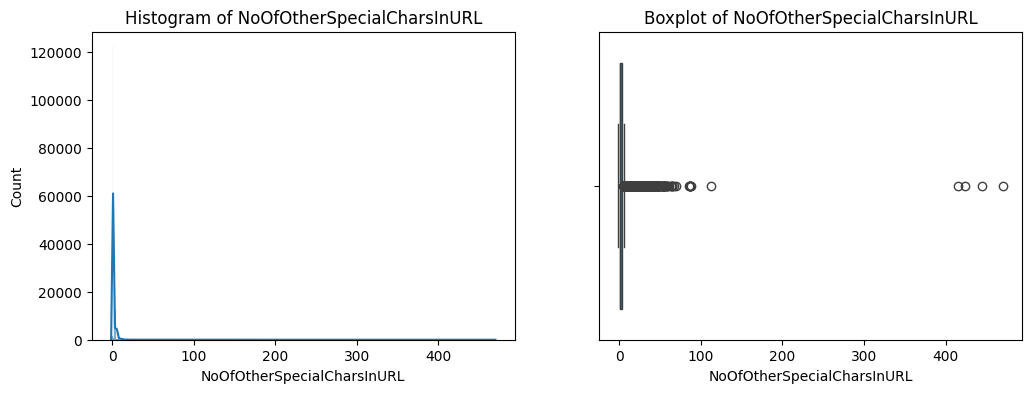

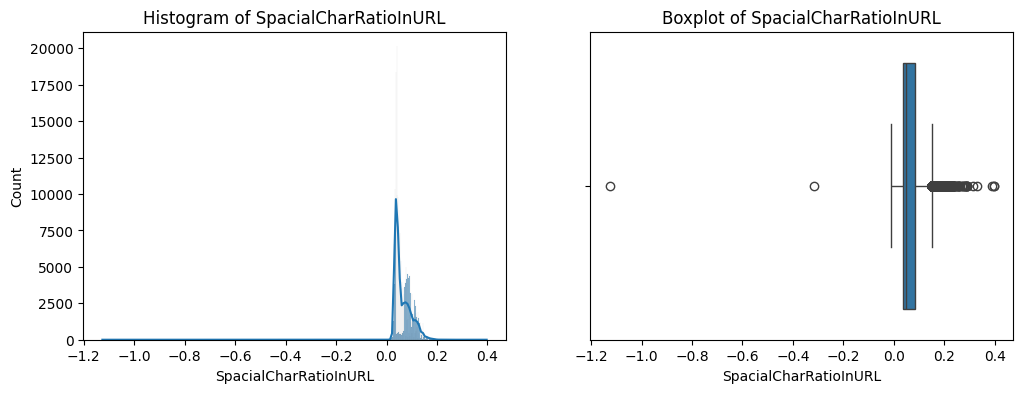

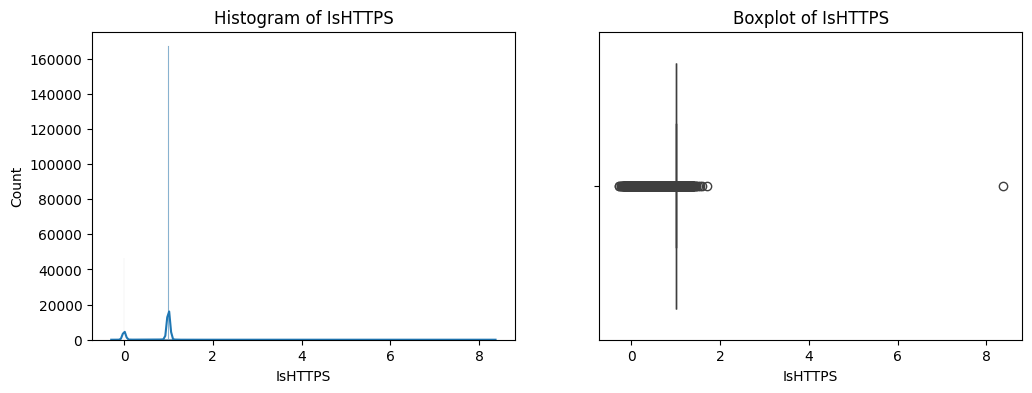

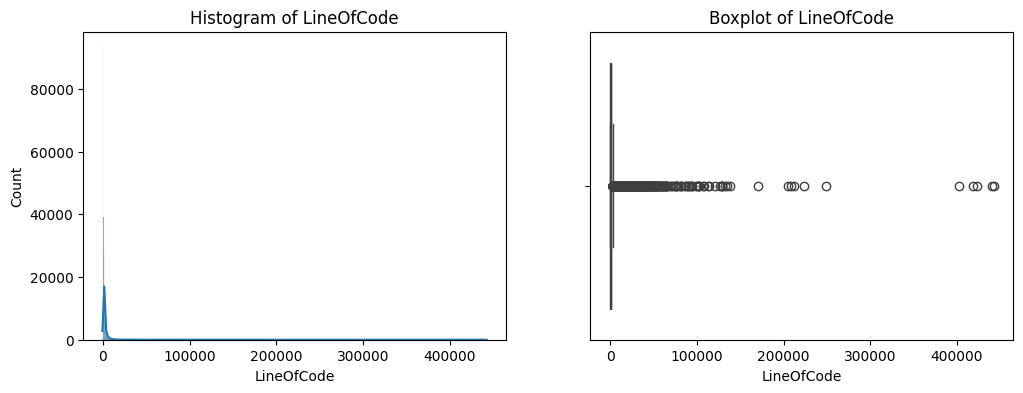

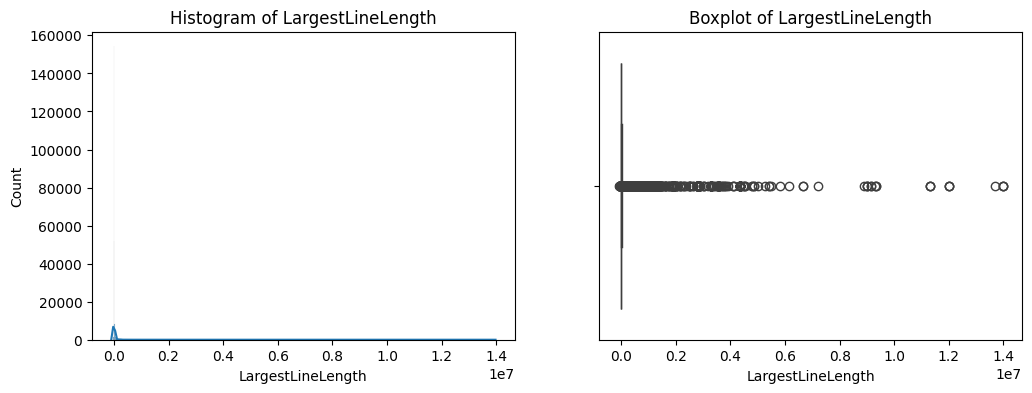

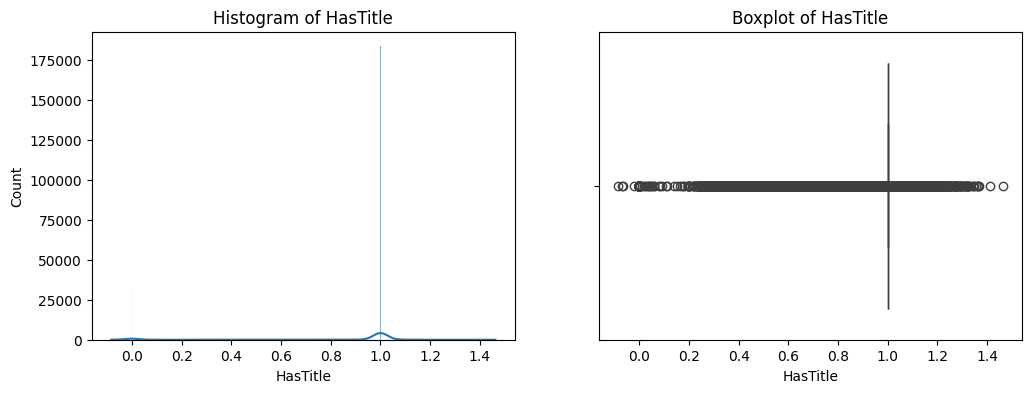

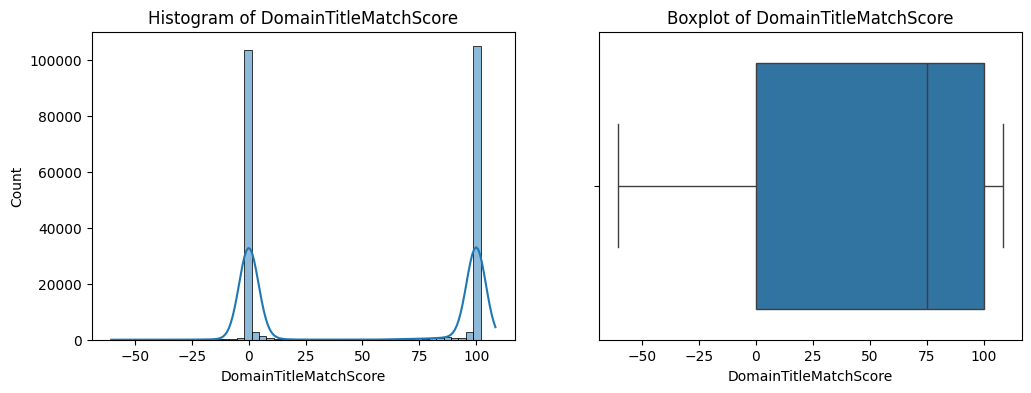

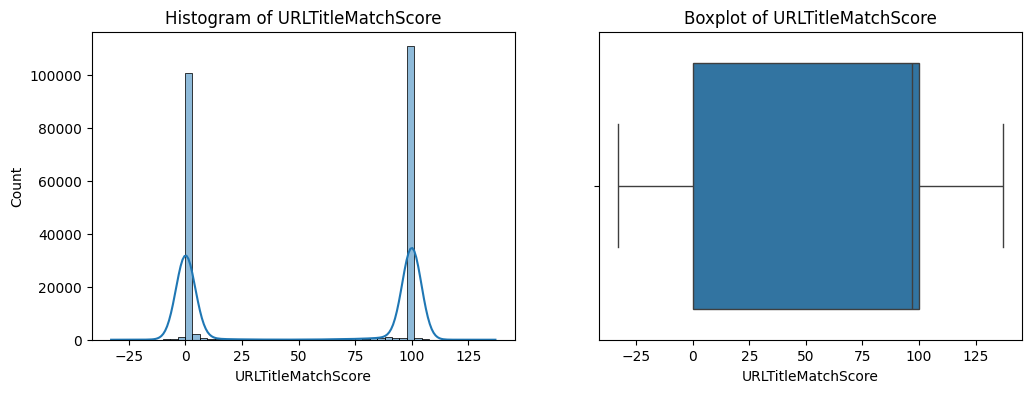

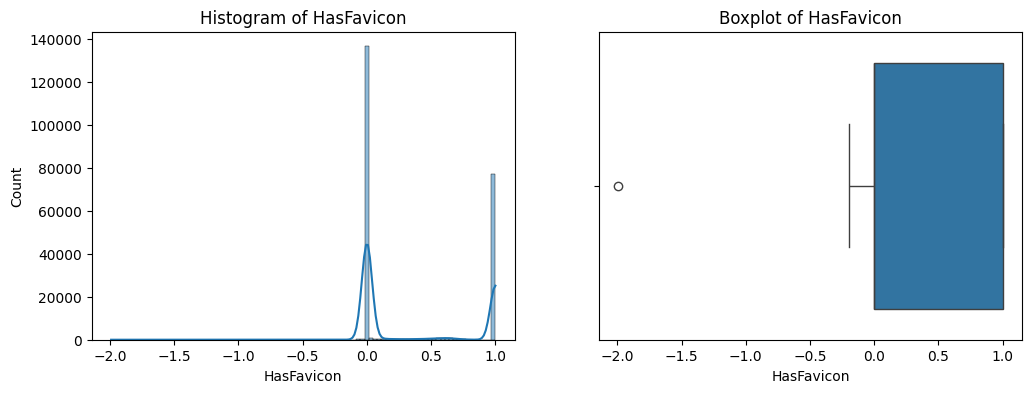

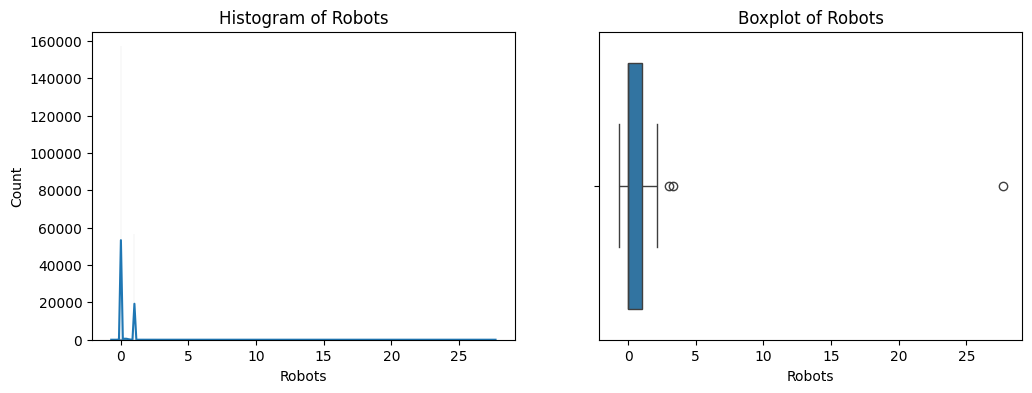

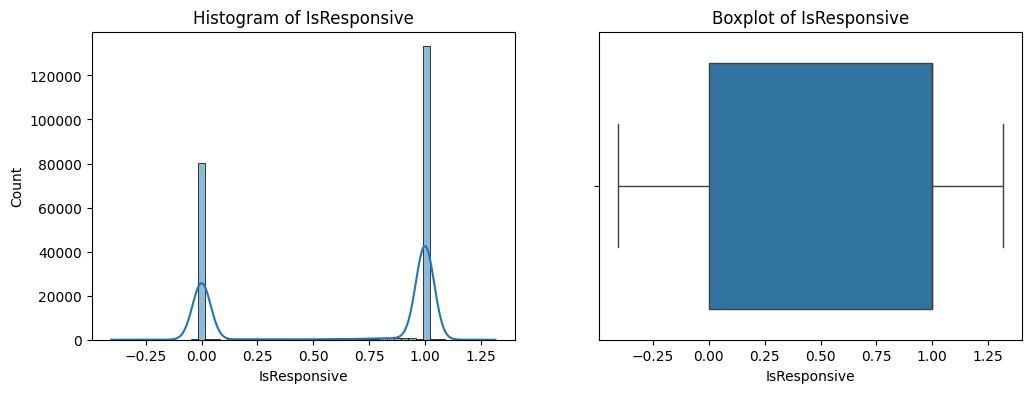

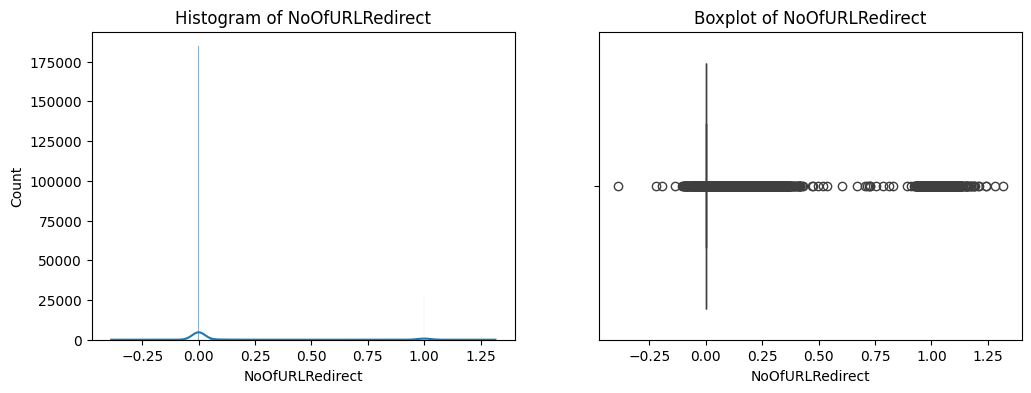

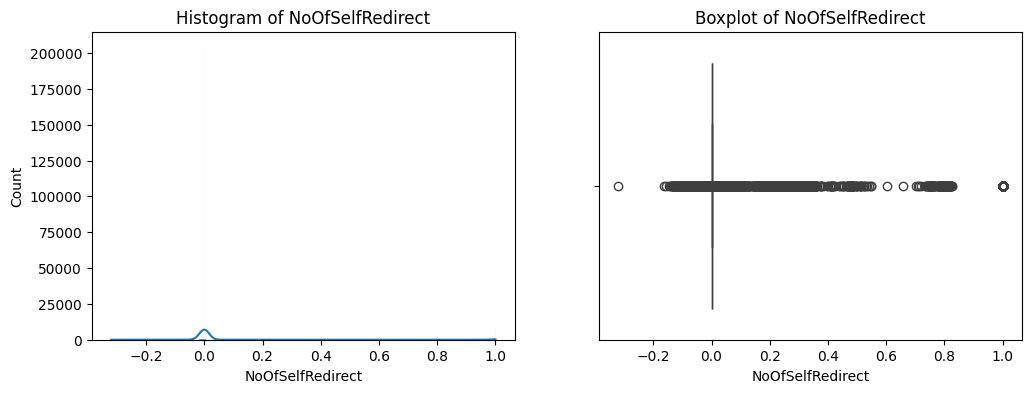

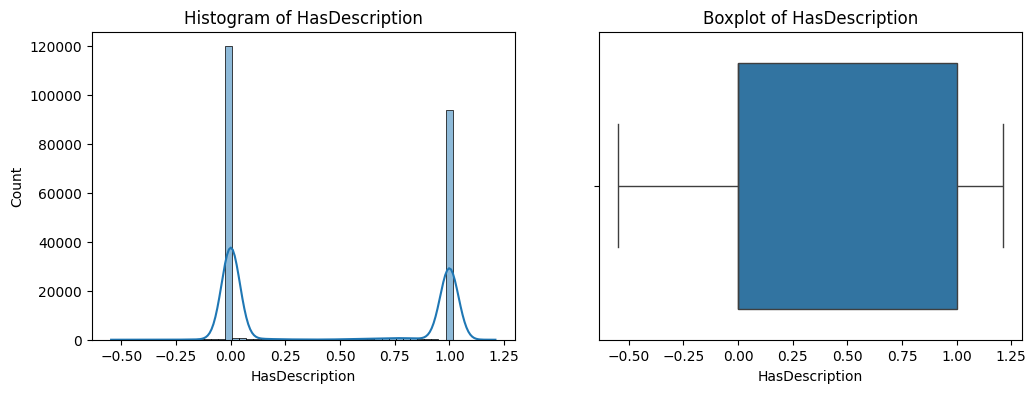

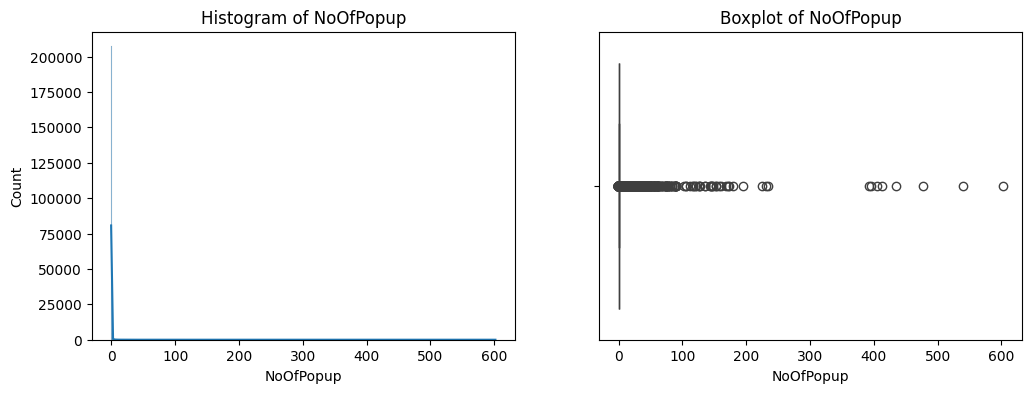

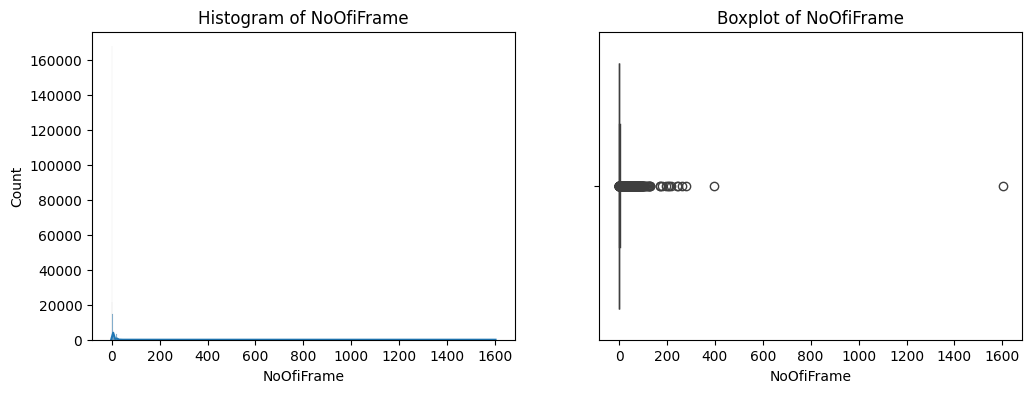

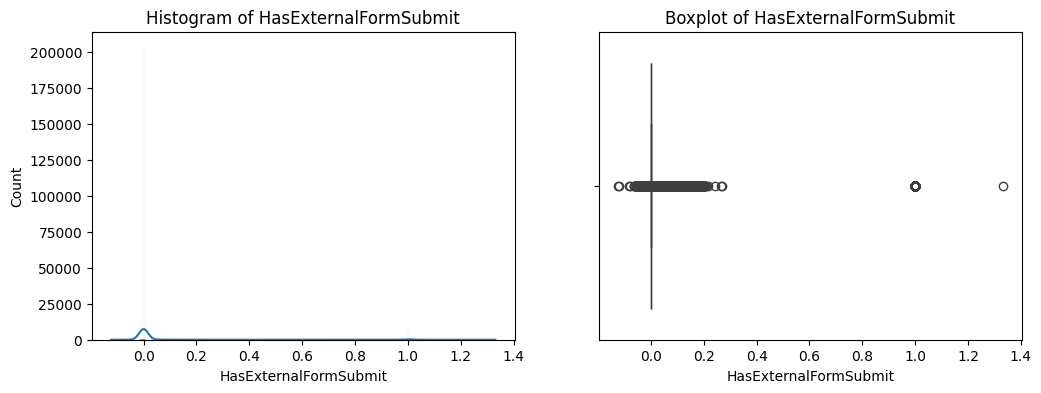

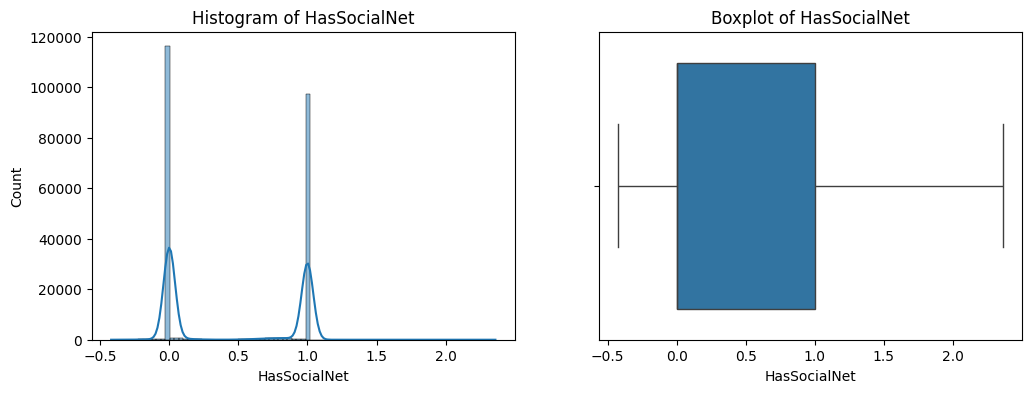

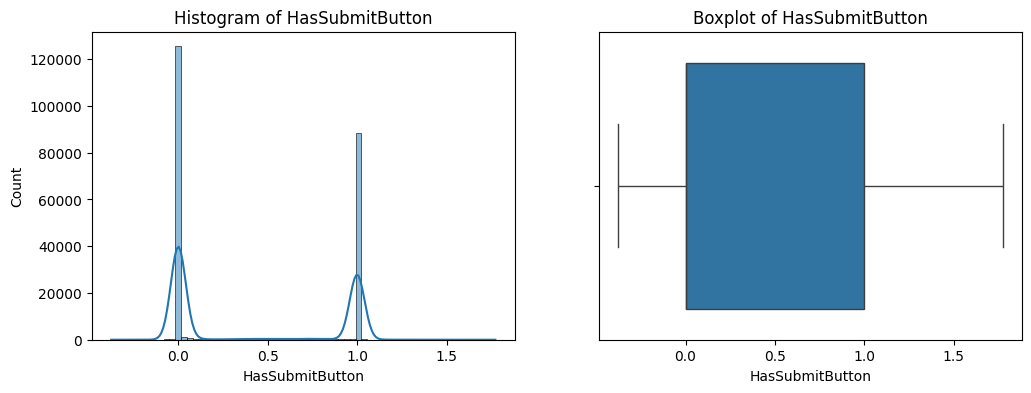

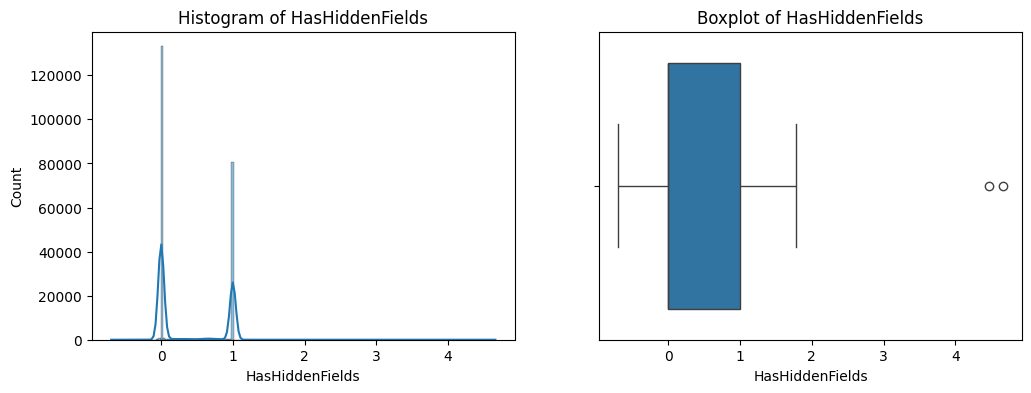

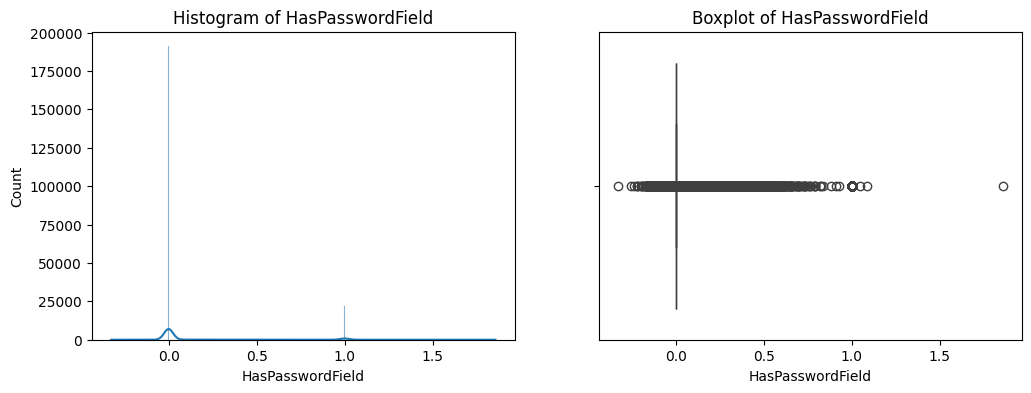

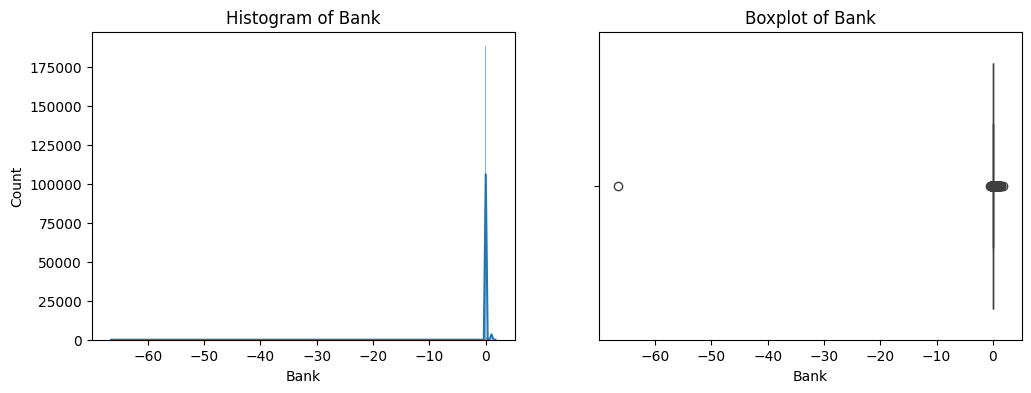

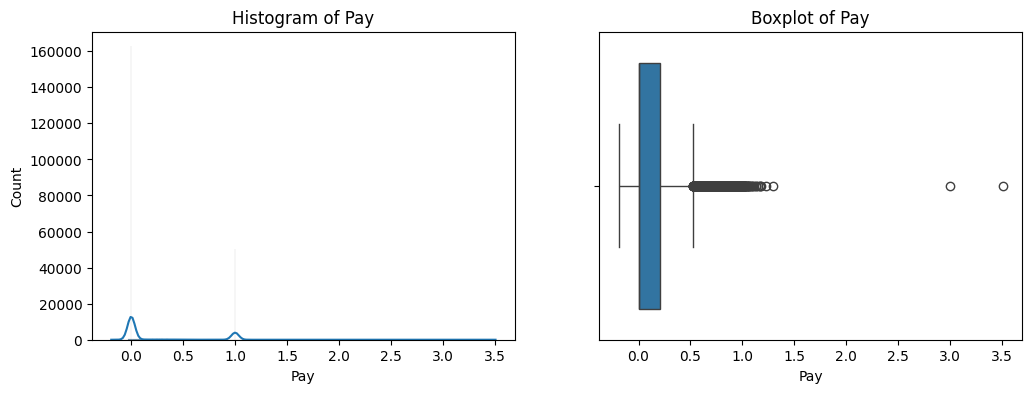

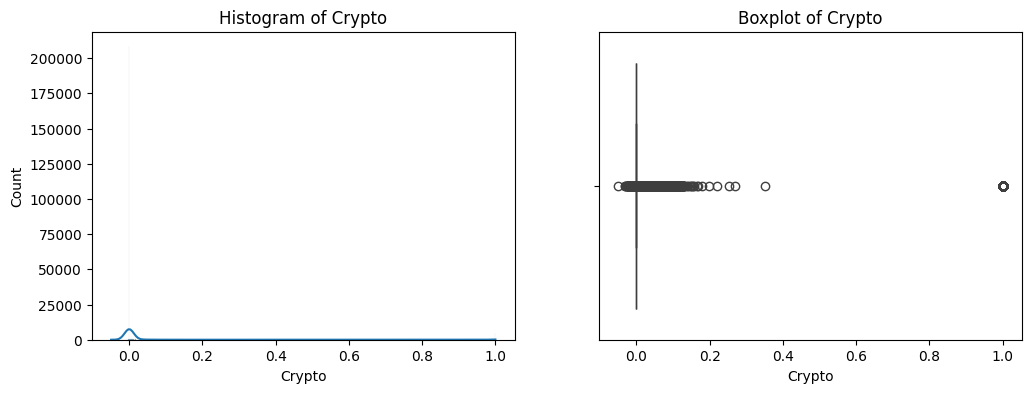

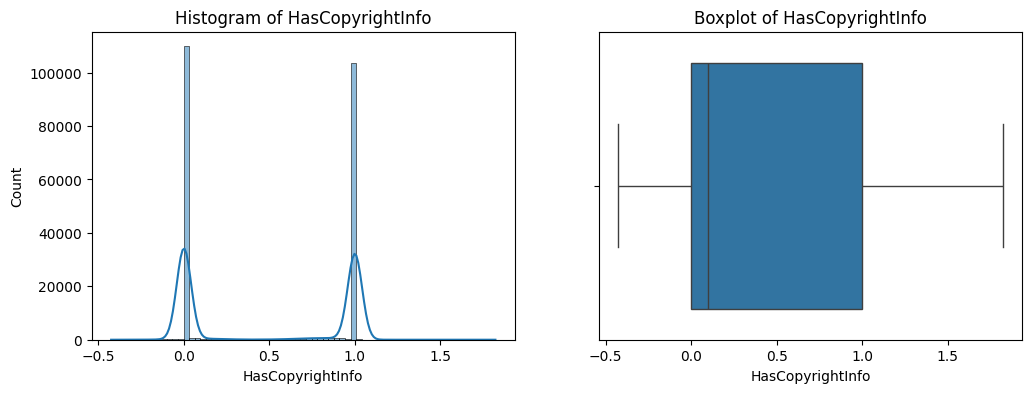

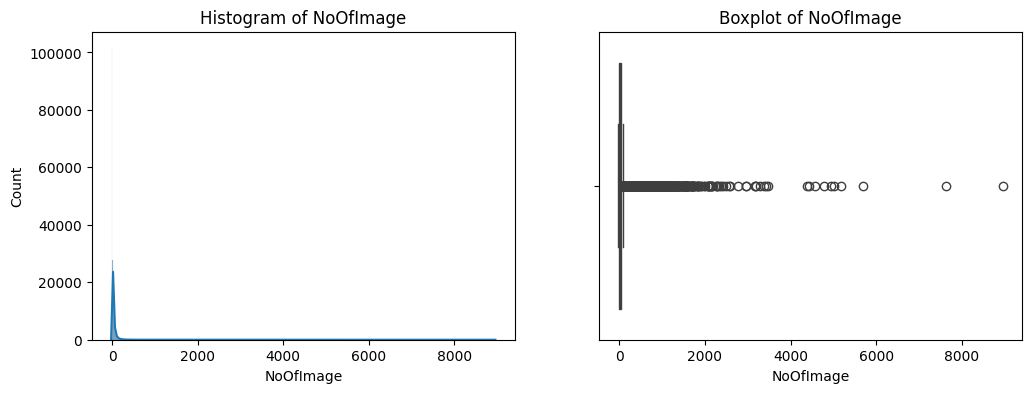

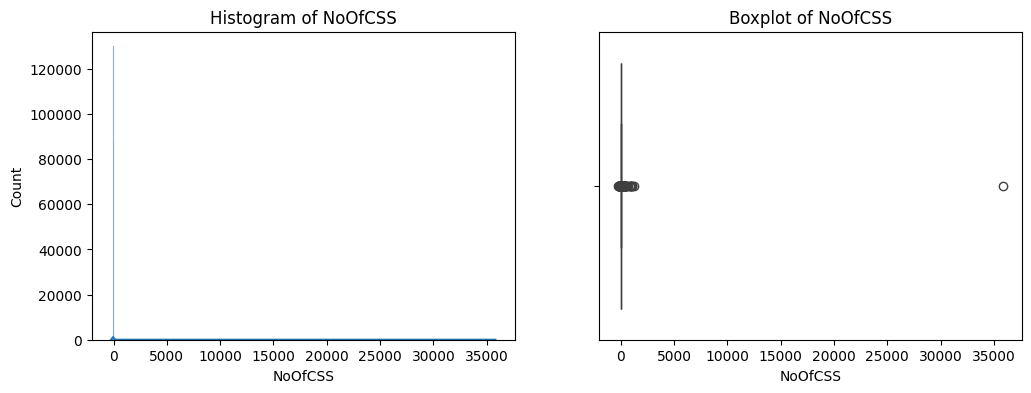

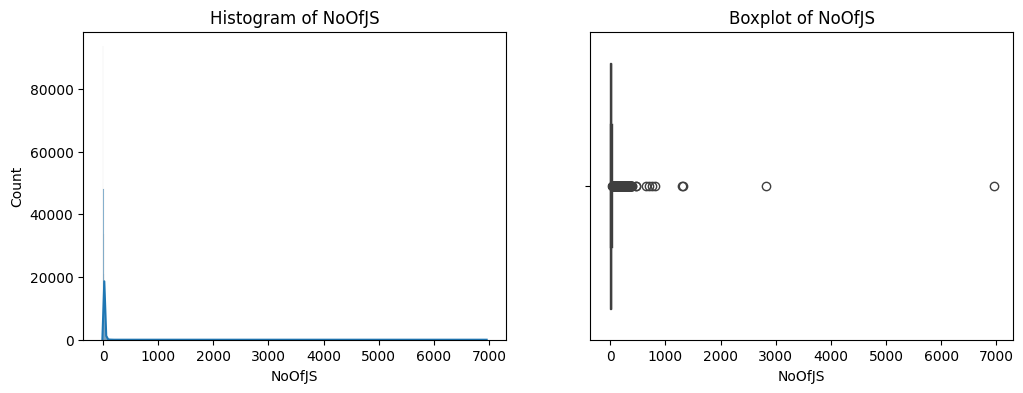

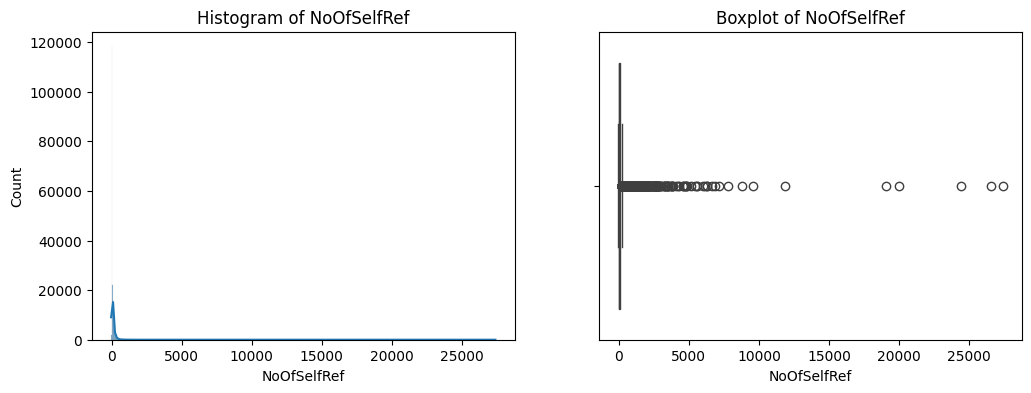

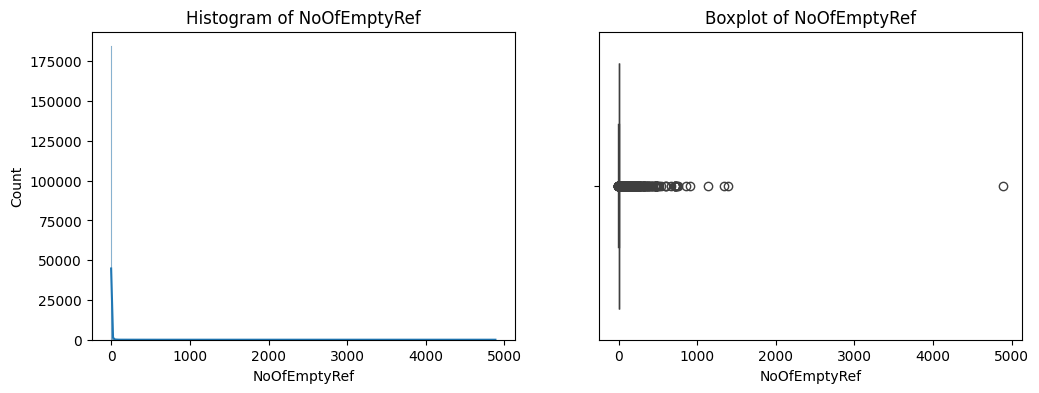

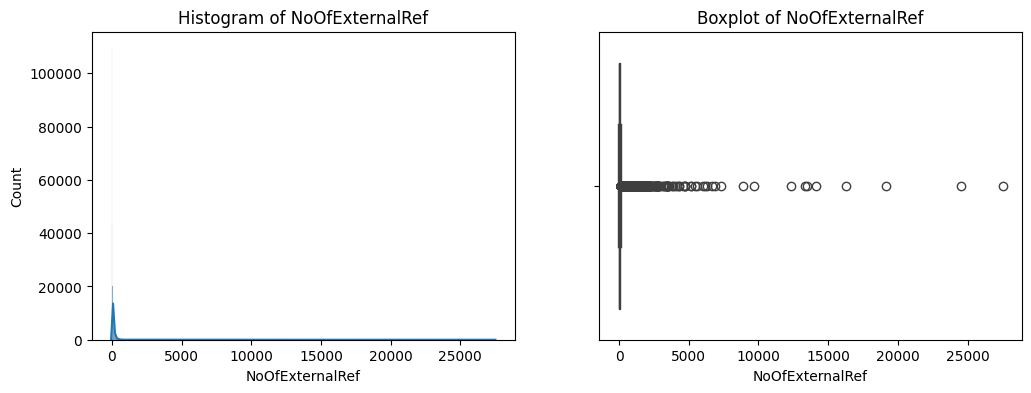

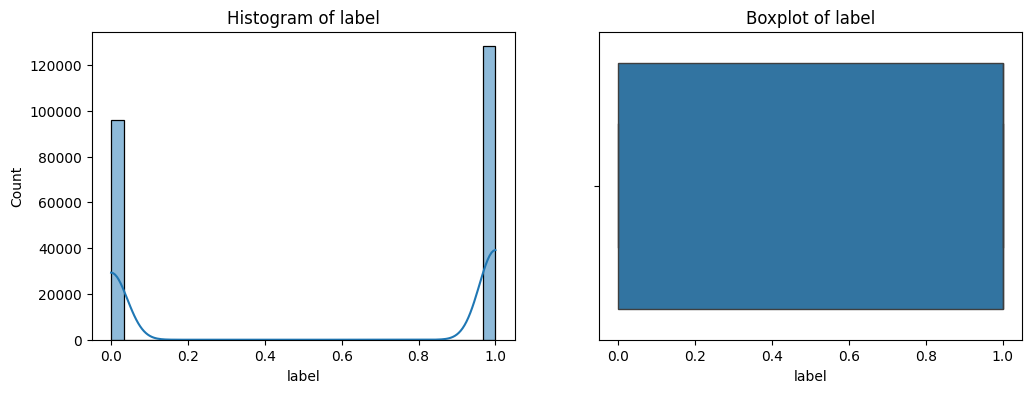

In [4]:
# Summary statistics for numerical columns
num_summary = df[num_cols].describe().T
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[col], ax=axes[0], kde=True)
    sns.boxplot(x=df[col], ax=axes[1])
    axes[0].set_title(f'Histogram of {col}')
    axes[1].set_title(f'Boxplot of {col}')
    plt.show()

I have outlier for almost every numeric column exsept binary column I need to change their type in feature eng part to arrange my data model.

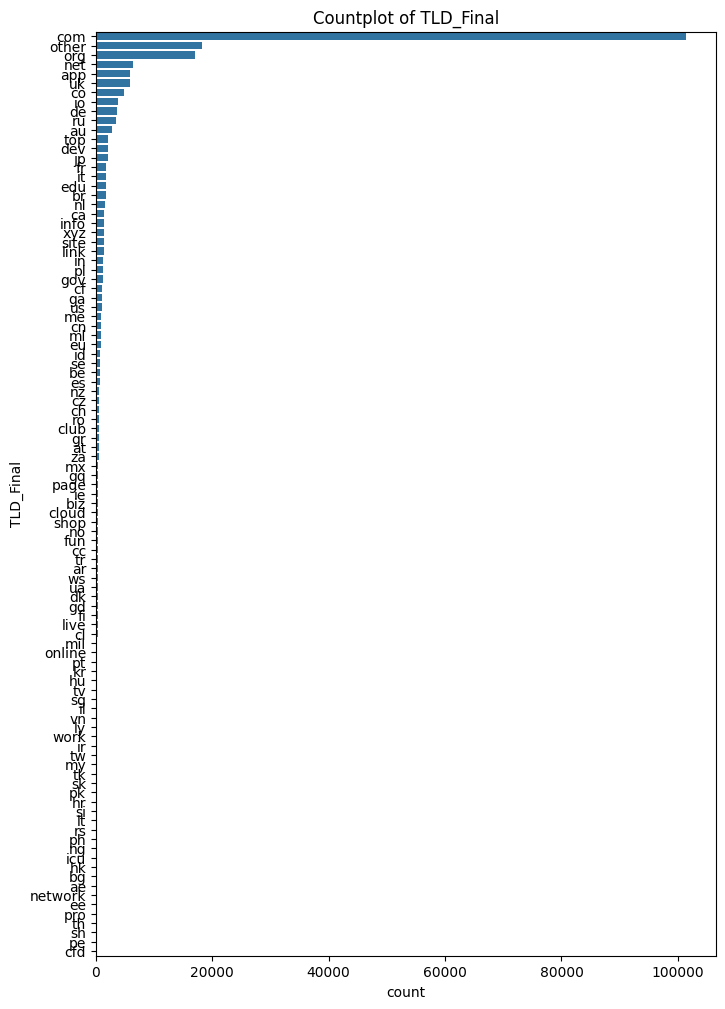

In [5]:
#categorical columns analysis
for col in cat_cols:
    plt.figure(figsize=(8, 12)) #we have lots of categories so we need to increase the figure size
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f'Countplot of {col}')
    plt.show()

well... I drop other 4 categorical data to clean my data bc of their are metadata not match or give meaningfull information to me. for my TLD categorical column we can see .com is dominationg the websites domains and follow by second and third most populer other is the sumation of under 100 frequency doamin expantion so variation of TDL a lot we can see that other categories are second most populer and third one .org for non-commercial intent and trust but we will examine how trust it is our future steps.

*Bivariate/Multivariate*

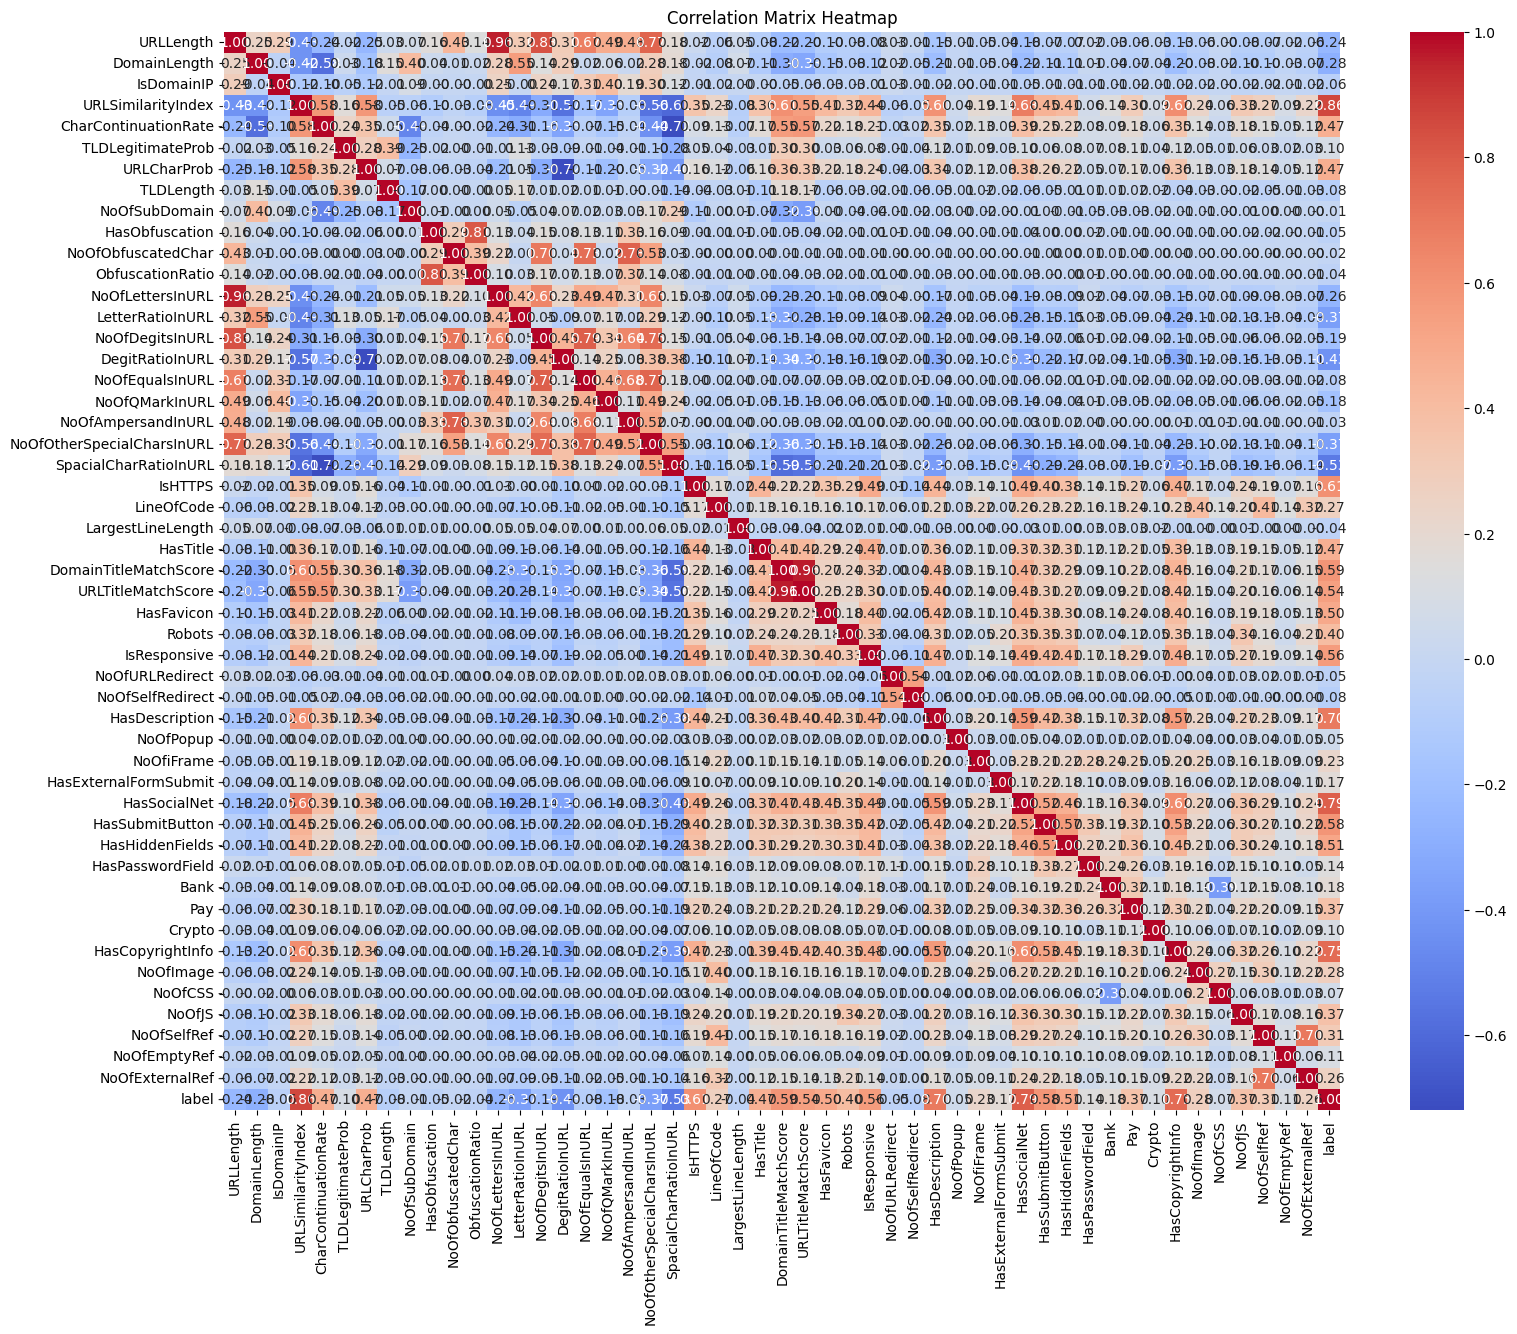

In [6]:
#corr matrix and heatmap
corr = df[num_cols].corr()
plt.figure(figsize=(18, 14))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

ther is a high related column to target variable 'label' positive and nevative also there is some positive correlation amount variabls. as a negative correlation spacialChainRatiolnURL observed...

In [ ]:
#categorical columns analysis ( do not run yet!)


ModuleNotFoundError: No module named 'statsmodels'

/var/folders/1y/vjrdcxhs2_l125ccbltlkq6h0000gn/T/ipykernel_1801/2660338468.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat_var, y=num_var, data=df, showfliers=False, palette="Set2")


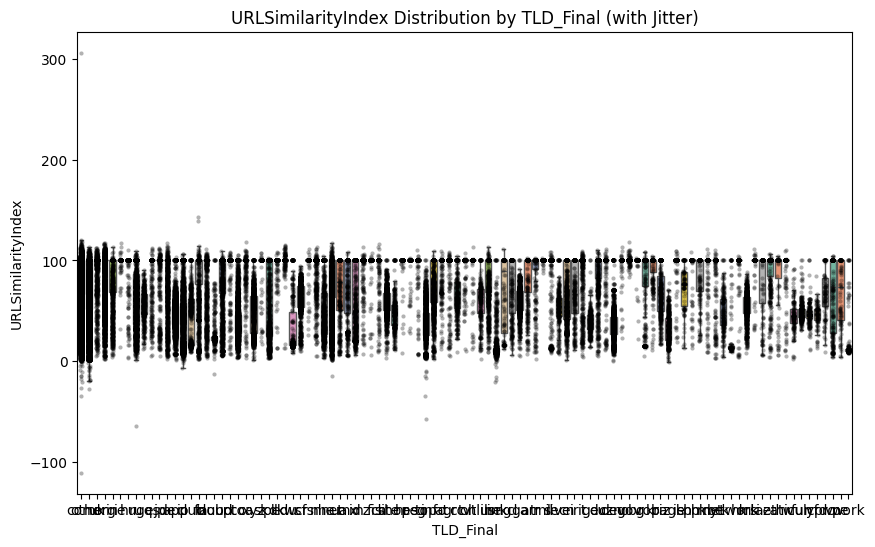

In [8]:
#boxplts with jitter
num_var = num_cols[3]  # change it here to any numerical variable you want to analyze
cat_var = cat_cols[0]  
plt.figure(figsize=(10, 6))

# 1. Create the Boxplot (Turn off outliers 'fliers' so they don't overlap with jitter)
sns.boxplot(x=cat_var, y=num_var, data=df, showfliers=False, palette="Set2")

# 2. Add Jitter (Strip plot)
sns.stripplot(x=cat_var, y=num_var, data=df, color='black', size=3, alpha=0.3, jitter=True)

plt.title(f"{num_var} Distribution by {cat_var} (with Jitter)")
plt.show()

Confirmatory Data Analysis

/var/folders/1y/vjrdcxhs2_l125ccbltlkq6h0000gn/T/ipykernel_1801/1475923720.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='URLLength', data=df, showfliers=False, palette="coolwarm")


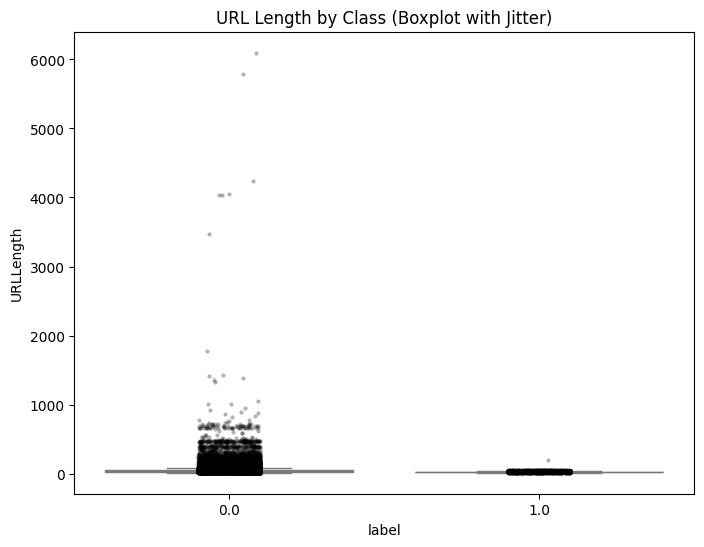

In [11]:
#boxplot label vs URLlength
plt.figure(figsize=(8, 6))
# Boxplot shows the quartiles
sns.boxplot(x='label', y='URLLength', data=df, showfliers=False, palette="coolwarm")
# Stripplot adds the "Jitter" (individual points)
sns.stripplot(x='label', y='URLLength', data=df, color='black', size=3, alpha=0.3, jitter=True)
plt.title("URL Length by Class (Boxplot with Jitter)")
plt.show()

/var/folders/1y/vjrdcxhs2_l125ccbltlkq6h0000gn/T/ipykernel_1801/285943136.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='Log_URLLength', data=df, palette="viridis")


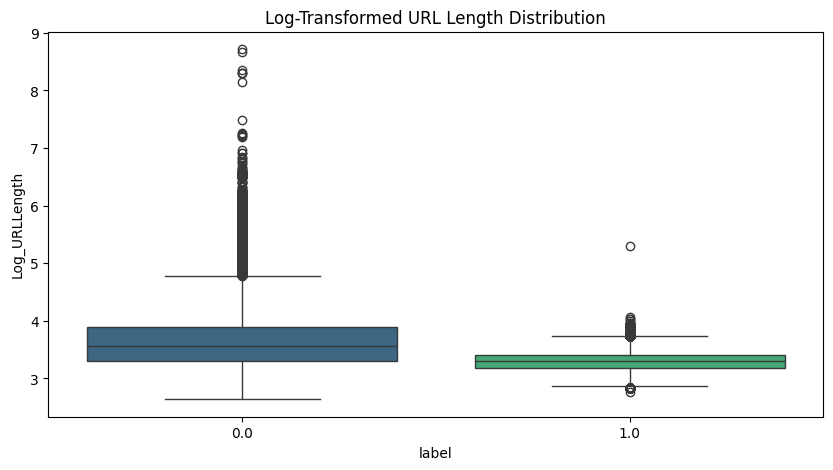

In [13]:
# Log-transform URLLength for better visualization
df['Log_URLLength'] = np.log1p(df['URLLength'])  

plt.figure(figsize=(10, 5))

sns.boxplot(x='label', y='Log_URLLength', data=df, palette="viridis")
plt.title('Log-Transformed URL Length Distribution')
plt.show()

URL leng more likely to be small to be legitimate

part-D hypotesis tests:

In [ ]:
import pandas as pd
from scipy.stats import shapiro, levene, bartlett, ttest_ind, mannwhitneyu

def hypothesis_testing_pipeline(df, variable_list, target_col='Label'):
    results = []

    for feature in variable_list:
        # 1. Split data into two groups
        group0 = df[df[target_col] == 0][feature].dropna() # Phishing
        group1 = df[df[target_col] == 1][feature].dropna() # Legitimate
        
        # 2. Assumption Check: Normality (Shapiro-Wilk)
        # Sampling 5000 if N is large to avoid excessive sensitivity
        stat0, p_norm0 = shapiro(group0) if len(group0) < 5000 else shapiro(group0.sample(5000))
        stat1, p_norm1 = shapiro(group1) if len(group1) < 5000 else shapiro(group1.sample(5000))
        
        is_normal = (p_norm0 > 0.05) and (p_norm1 > 0.05)
        
        # 3. Assumption Check: Homogeneity of Variance (Conditional)
        if is_normal:
            # If Normal -> Use Bartlett
            stat_var, p_var = bartlett(group0, group1)
            var_test_name = "Bartlett"
        else:
            # If Not Normal -> Use Levene
            stat_var, p_var = levene(group0, group1)
            var_test_name = "Levene"
            
        # 4. Apply the Final Statistical Test
        if is_normal:
            # Parametric: T-Test (Check equal_var based on variance test result)
            stat, p_value = ttest_ind(group0, group1, equal_var=(p_var > 0.05))
            final_test_name = "T-Test"
        else:
            # Non-Parametric: Mann-Whitney U
            stat, p_value = mannwhitneyu(group0, group1)
            final_test_name = "Mann-Whitney U"
            
        results.append({
            "Feature": feature,
            "Normality_Met": is_normal,
            "Variance_Test_Used": var_test_name,
            "Variance_p_Value": round(p_var, 4),
            "Final_Test_Used": final_test_name,
            "Final_p_Value": p_value,
            "Significant": "YES" if p_value < 0.05 else "NO"
        })

    return pd.DataFrame(results)
# Specify numeric variables to test
my_continuous_vars = ['URLLength','DomainLength','URLSimilarityIndex','CharContinuationRate','TLDLegitimateProb','URLCharProb','LetterRatioInURL','SpacialCharRatioInURL']

# Run
df_results = hypothesis_testing_pipeline(df, my_continuous_vars, target_col='label')
print(df_results)

                 Feature  Normality_Met Variance_Test_Used  Variance_p_Value  \
0              URLLength          False             Levene               0.0   
1           DomainLength          False             Levene               0.0   
2     URLSimilarityIndex          False             Levene               0.0   
3   CharContinuationRate          False             Levene               0.0   
4      TLDLegitimateProb          False             Levene               0.0   
5            URLCharProb          False             Levene               0.0   
6       LetterRatioInURL          False             Levene               0.0   
7  SpacialCharRatioInURL          False             Levene               0.0   

  Final_Test_Used  Final_p_Value Significant  
0  Mann-Whitney U            0.0         YES  
1  Mann-Whitney U            0.0         YES  
2  Mann-Whitney U            0.0         YES  
3  Mann-Whitney U            0.0         YES  
4  Mann-Whitney U            0.0         YES

Normality assumptions were checked using the Shapiro-Wilk test for all continuous variables. Results indicated that none of the features followed a normal distribution ($p < 0.05$). Consequently, parametric tests (T-Test, ANOVA) were deemed unsuitable.To ensure robust statistical inference, the non-parametric Mann-Whitney U test was applied for hypothesis testing. This test does not assume normality and is effective for comparing the distributions of Phishing and Legitimate URLs